In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#scikit learn: python的機器學習套件
#以下匯入資料前處理、PCA、分類模型、交叉驗證及模型評估所需的工具
from sklearn.preprocessing import StandardScaler #把不同features的尺度統一
from sklearn.pipeline import Pipeline #規定資料要按照什麼順序被處理，且防止處理過程偷看到test data

#利用week3的程式分別讀取healthy/ crc/ covid的csv檔案
healthy = pd.read_csv("healthy.csv")
covid = pd.read_csv("covid.csv")
crc = pd.read_csv("crc.csv")

#將三個檔案合併成一個csv檔案
data = pd.concat([healthy, covid, crc], ignore_index=True)


X = data.drop(columns= ["sample_id", "subject_id", "label"]) #將這三個columns刪掉後的資料存入x，避免data leakage
y = data["label"]
groups = (data["label"].astype(str) + "_" + data["subject_id"].astype(str)) #讓GroupKFold 知道哪些資料屬於同一個人
#且避免資料命名一樣

from sklearn.decomposition import PCA

#做PCA前標準化features，避免不同尺度影響
#fit(): 看資料，算出每個feature的平均值和標準差
#transform(): 用算出的mean和std 將資料轉換成標準化數值
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

pca = PCA(n_components=2) #將80維的資料降到2維
X_pca = pca.fit_transform(X_scaled) #做PCA


(80, 2)


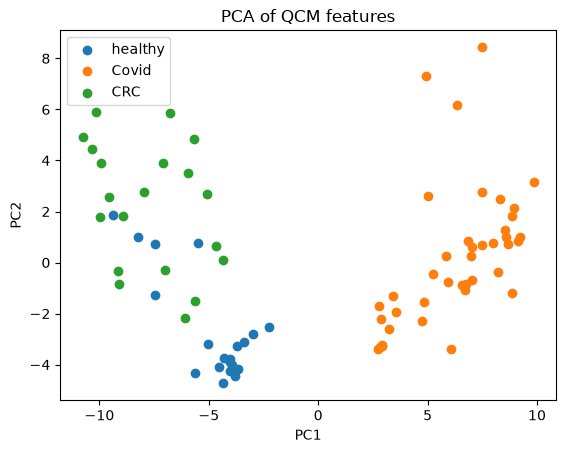

[0.56137417 0.11507388]
0.6764480459726612


In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"]) #把PCA結果整理成dataframe，並將兩欄命名為PC1&PC2
pca_df["label"] = y.values #加入疾病label，方便畫圖

for label in pca_df["label"].unique(): ##找出label這欄有哪些不重複的值
    group = pca_df[pca_df["label"] == label] #每次只挑出目前這個疾病的資料

    plt.scatter(group["PC1"], group["PC2"], label = label) #把目前這個疾病畫成散點圖

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of QCM features")
plt.legend()
plt.show()

print(pca.explained_variance_ratio_) #這兩個PC到底保留了原始80維資料的多少資訊 #PC1:0.52/ PC2:0.16
print(pca.explained_variance_ratio_.sum()) #這張圖總共呈現了幾%變異 #68%

In [ ]:
from sklearn.model_selection import GroupKFold
# 根據groups的受試者分組資訊，將x/y分成不同的train/test folds，且同一個groups不能被拆開
gkf = GroupKFold(n_splits=4) #分成4組

#可以印出GroupKFold
# for fold, (train_index, test_index) in enumerate(gkf.split(X, y, groups)):
#     print(f"Fold{fold + 1}")

#     print("Train subjects: ")
#     print(data.iloc[train_index]["subject_id"].tolist())
#     print("Test subjects: ")
#     print(data.iloc[test_index]["subject_id"].tolist())
#     print()

Fold1
Train subjects: 
[18, 19, 20, 23, 25, 29, 36, 40, 41, 46, 49, 50, 60, 68, 71, 64, 91, 92, 95, 102, 106, 110, 126, 129, 131, 210, 213, 220, 230, 232, 234, 239, 255, 257, 279, 286, 287, 301, 391, 392, 399, 400, 404, 417, 425, 7, 9, 10, 12, 14, 26, 31, 45, 54, 59, 61, 76, 77, 80, 95]
Test subjects: 
[22, 32, 44, 51, 84, 65, 99, 112, 132, 223, 236, 270, 294, 394, 406, 5, 8, 21, 64, 96]

Fold2
Train subjects: 
[18, 19, 22, 23, 25, 32, 36, 40, 44, 46, 49, 51, 60, 68, 84, 65, 91, 92, 99, 102, 106, 112, 126, 129, 132, 210, 213, 223, 230, 232, 236, 239, 255, 270, 279, 286, 294, 301, 391, 394, 399, 400, 406, 417, 425, 5, 7, 8, 9, 10, 12, 21, 26, 31, 54, 59, 64, 76, 80, 96]
Test subjects: 
[20, 29, 41, 50, 71, 64, 95, 110, 131, 220, 234, 257, 287, 392, 404, 14, 45, 61, 77, 95]

Fold3
Train subjects: 
[18, 20, 22, 23, 29, 32, 36, 41, 44, 46, 50, 51, 60, 71, 84, 64, 65, 91, 95, 99, 102, 110, 112, 126, 131, 132, 210, 220, 223, 230, 234, 236, 239, 257, 270, 279, 287, 294, 301, 392, 394, 399, 40

In [ ]:
#建立LDA模型，訓練fold
#找出最能區分不同類別的方向

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#將StandardScaler 放在Pipeline內
#讓每一個fold只使用training data 計算標準差參數，避免leakage
lda_pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", LinearDiscriminantAnalysis())
    ])

y_true = [] #fold的真實答案
y_pred = [] #fold的預測答案

#fold每次都會說那些row當training/testing
for train_index, test_index in gkf.split(X, y, groups): 
    X_train = X.iloc[train_index] #從x取出訓練用的features
    X_test = X.iloc[test_index] #取出測試用的

    y_train = y.iloc[train_index] #從y取出training data 的正確疾病答案
    y_test = y.iloc[test_index] #test data的正確答案

    lda_pipeline.fit(X_train, y_train) #用training data訓練LDA

    pred = lda_pipeline.predict(X_test) #把test data丟進訓練好的模型，讓他預測疾病

    #把每一次fold的結果接到原本list的後面
    y_true.extend(y_test)
    y_pred.extend(pred)

print("True: ") #印出答案
print(y_true)

print("\nPredicted: ") #印出預測
print(y_pred)

#匯入評估指標
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true, y_pred) #全部的sample，有多少比例猜對 (正確率)
macro_f1 = f1_score(y_true, y_pred, average = "macro") #分別算出healthy/ covid/ crc的f1再平均
print("Accuracy: ", accuracy) #全部人加起來，有多少比例猜對
print("Macro-F1: ", macro_f1) #三類分開評分，然後平等權重平均(不看樣本數)
#避免樣本數較多的類別主導整體評估結果

True: 
['healthy', 'healthy', 'healthy', 'healthy', 'healthy', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'healthy', 'healthy', 'healthy', 'healthy', 'healthy', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'healthy', 'healthy', 'healthy', 'healthy', 'healthy', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'healthy', 'healthy', 'healthy', 'healthy', 'healthy', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'Covid', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC']

Predicted: 
[np.str_('CRC'), np.str_('healthy'), np.str_('healthy'), np.str_('healthy'), np.str_('healthy'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), np.str_('Covid'), 

In [ ]:
#建立SVM模型，訓練fold
#想辦法在不同類別的資料間，找到一條最適合的，距離最近資料點都盡量遠的分界線

from sklearn.svm import SVC

#尋找線性kernel=linear的分類邊界
svm_pipeline = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="linear"))])

svm_true = []
svm_pred = []
#svm_sample_ids = []

#使用GroupKFold 進行交叉驗證
for train_index, test_index in gkf.split(X, y, groups):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    #訓練SVM
    svm_pipeline.fit(X_train, y_train) #training data訓練SVM
    pred = svm_pipeline.predict(X_test) #把沒參與的X_test給SVM，請他猜healthy/ covid/ crc

    svm_true.extend(y_test)
    svm_pred.extend(pred)

    #svm_sample_ids.extend(data.iloc[test_index]["sample_id"])

svm_accuracy = accuracy_score(svm_true, svm_pred)
svm_macro_f1 = f1_score(svm_true, svm_pred, average="macro")

print("SVM Accuracy: ", svm_accuracy)
print("SVM Macro-F1: ", svm_macro_f1)


SVM Accuracy:  1.0
SVM Macro-F1:  1.0


In [ ]:
#建立RandomForest模型
#建立很多決策樹，讓每顆樹各自判斷，最後用多數決定答案

from sklearn.ensemble import RandomForestClassifier

#建100棵決策樹
#固定隨機抽樣結果，使分析可以重現
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))])

rf_true = []
rf_pred = []

for train_index, test_index in gkf.split(X, y, groups):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    rf_pipeline.fit(X_train, y_train)
    pred = rf_pipeline.predict(X_test)

    rf_true.extend(y_test)
    rf_pred.extend(pred)

rf_accuracy = accuracy_score(rf_true, rf_pred)
rf_macro_f1 = f1_score(rf_true, rf_pred, average="macro")

print("Random Forest Accuracy: ", rf_accuracy)
print("Random Forest Macro-F1: ", rf_macro_f1)

Random Forest Accuracy:  1.0
Random Forest Macro-F1:  1.0


In [ ]:
#公平比較三個模型的cross-validation

#將三個模型放進同一個dictionary
models ={"LDA":lda_pipeline, "SVM":svm_pipeline, "Random Forest":rf_pipeline}

#建立空list，存放最後結果
results = []

for model_name, model in models.items(): #models.items()會一次拿出名稱+模型
    fold_accuracies = [] #模型準備自己的結果
    fold_f1s = []

    for train_index, test_index in gkf.split(X, y, groups):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        fold_accuracy = accuracy_score(y_test, pred) #這一個fold考完了
        fold_f1 = f1_score(y_test, pred, average="macro") #算Accuracy和Macro-F1

        fold_accuracies.append(fold_accuracy) #把fold的成績放進list
        fold_f1s.append(fold_f1)

    results.append({
        "Model":model_name,
        "CV Accuracy": np.mean(fold_accuracies),
        "CV Macro-F1": np.mean(fold_f1s) #CV=Corss-Validation
    })


results_df = pd.DataFrame(results) #將三個模型的平均結果整理成表格
print(results_df)



           Model  CV Accuracy  CV Macro-F1
0            LDA        0.975     0.966667
1            SVM        1.000     1.000000
2  Random Forest        1.000     1.000000


[[20  0  0]
 [ 0 40  0]
 [ 0  0 20]]


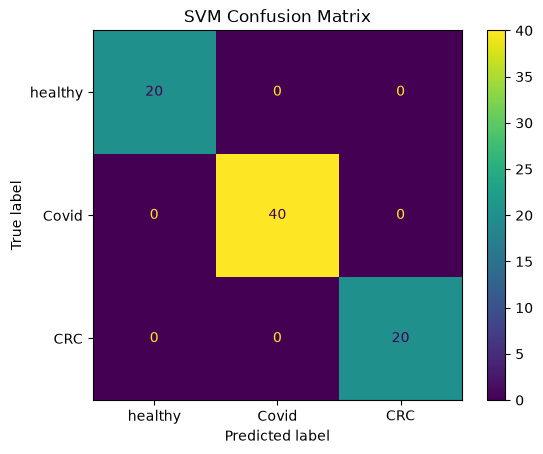

In [ ]:
#做混淆矩陣confusion matrix :直接說哪一類被錯認成哪一類
#row代表真實類別，column代表模型預測類別
svm_cm = confusion_matrix(svm_true, svm_pred, labels=["healthy", "Covid", "CRC"])
print(svm_cm)

#將amtrix視覺化
#對角線:猜對
disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=["healthy", "Covid", "CRC"])
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
#因為前面做出100%的模型，所以將label隨機打亂，破壞QCM features與真實疾病之間的關係
#用來確認原本的高準確率不是模型再隨機資料上也能輕易取得

y_shuffled = y.sample(
    frac=1, #全部資料抽出來，順序打亂
    random_state=42
).reset_index(drop=True) #重新整理index

groups_shuffled = groups.reset_index(drop=True) #保留原本的subject grouping

shuffle_true = []
shuffle_pred = []

for train_index, test_index in gkf.split(
    X, y_shuffled, groups_shuffled
):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y_shuffled.iloc[train_index]
    y_test = y_shuffled.iloc[test_index]

    svm_pipeline.fit(X_train, y_train)

    pred = svm_pipeline.predict(X_test)

    shuffle_true.extend(y_test)
    shuffle_pred.extend(pred)

#若lable被打亂後模型表現大幅下降
#表示原本的分類能力依賴QCM features 與真實label的關係
print(
    "Shuffled Accuracy:",
    accuracy_score(shuffle_true, shuffle_pred)
)

print(
    "Shuffled Macro-F1:",
    f1_score(
        shuffle_true,
        shuffle_pred,
        average="macro"
    )
)

Shuffled Accuracy: 0.2625
Shuffled Macro-F1: 0.19967532467532467
